<a href="https://colab.research.google.com/github/Chan0418/animal-condition-classification/blob/main/animal_condition_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Animal Disease Classification

## Project overview

This project develops a supervised machine-learning approach for predicting whether an animal health condition is classified as dangerous. The prediction uses the animal type and five recorded symptom fields.

### Research question

Can animal type and reported symptoms be used to predict whether a case is classified as dangerous?

### Project workflow

1. Load and inspect the dataset
2. Standardize animal and symptom information
3. Explore the target distribution and common symptoms
4. Train and compare classification models
5. Evaluate model performance on an unseen test set

### Limitation

It is not a veterinary diagnostic system. The dataset is substantially imbalanced, so model performance must be interpreted using multiple evaluation metrics rather than accuracy alone.

## 0. Install dependencies

Run this cell if the required Python packages are not already available in the notebook environment.

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn kagglehub

## 1. Load and inspect the data

The notebook first checks for a local `data.csv` file. If it is not available, it attempts to load the dataset through KaggleHub.

The initial inspection confirms that the dataset has loaded correctly and provides an overview of its structure and column types.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 42
TARGET = "Dangerous"
SYMPTOMS = ["symptoms1", "symptoms2", "symptoms3", "symptoms4", "symptoms5"]

# Load locally first; otherwise use the KaggleHub source.
data_path = Path("data.csv")
if data_path.exists():
    df_raw = pd.read_csv(data_path)
else:
    try:
        import kagglehub
        from kagglehub import KaggleDatasetAdapter
        df_raw = kagglehub.load_dataset(
            KaggleDatasetAdapter.PANDAS,
            "gracehephzibahm/animal-disease",
            "data.csv",
        )
    except Exception:
        kaggle_path = Path("/kaggle/input/animal-disease/data.csv")
        if not kaggle_path.exists():
            raise FileNotFoundError(
                "Place data.csv beside this notebook, use Kaggle's input path, "
                "or enable KaggleHub access."
            )
        df_raw = pd.read_csv(kaggle_path)

print("Raw shape:", df_raw.shape)
display(df_raw.head())
print(df_raw.dtypes)

/tmp/ipykernel_1237/676945473.py:36: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_raw = kagglehub.load_dataset(


100%|██████████| 63.0k/63.0k [00:00<00:00, 289kB/s]

Raw shape: (871, 7)


,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes


AnimalName    object
symptoms1     object
symptoms2     object
symptoms3     object
symptoms4     object
symptoms5     object
Dangerous     object
dtype: object


## 2. Data preparation and cleaning

The original data contains differences in capitalization, spacing, punctuation, and several known spelling variations. These inconsistencies are standardized before the modeling stage.

The cleaning process uses explicit replacements rather than broad fuzzy matching. This reduces the risk of combining symptoms that are textually similar but clinically different.

The target variable is encoded as follows:

- `0`: not dangerous
- `1`: dangerous

In [2]:
def normalize_text(value):
    if pd.isna(value):
        return ""
    value = str(value).lower().strip().replace("\xa0", " ")
    value = re.sub(r"[_(),.\-]+", " ", value)
    return re.sub(r"\s+", " ", value).strip()

required = {TARGET, "AnimalName", *SYMPTOMS}
missing = required - set(df_raw.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df = df_raw.copy().rename(columns={"AnimalName": "Animal"})
for col in ["Animal", TARGET, *SYMPTOMS]:
    df[col] = df[col].map(normalize_text)

animal_map = {
    "birds": "bird", "fowl": "bird", "other birds": "bird",
    "chicken": "hen", "buffaloes": "buffalo", "dogs": "dog",
    "goats": "goat", "hyaenas": "hyaena", "pigs": "pig",
    "wolves": "wolf", "mules": "mule", "moos": "cow",
}
symptom_map = {
    "abdminal pain": "abdominal pain",
    "abdonormal pain": "abdominal pain",
    "abdonormal discomfort": "abdominal discomfort",
    "diffculty breathing": "difficulty breathing",
}
df["Animal"] = df["Animal"].replace(animal_map)
for col in SYMPTOMS:
    df[col] = df[col].replace(symptom_map)

# Keep only valid binary target labels, then encode explicitly.
df = df[df[TARGET].isin({"yes", "no"})].copy()
df[TARGET] = df[TARGET].map({"no": 0, "yes": 1})
df = df[df["Animal"] != ""].drop_duplicates().reset_index(drop=True)

for i, col in enumerate(SYMPTOMS, start=1):
    df.rename(columns={col: f"Symptom {i}"}, inplace=True)

FEATURES = ["Animal"] + [f"Symptom {i}" for i in range(1, 6)]
df = df[FEATURES + [TARGET]]

print("Clean shape:", df.shape)
print("\nTarget counts:")
print(df[TARGET].value_counts().rename(index={0: "not dangerous", 1: "dangerous"}))
display(df.head())
df.to_csv("clean_data.csv", index=False)

Clean shape: (839, 7)

Target counts:
Dangerous
dangerous        819
not dangerous     20
Name: count, dtype: int64


,Animal,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Dangerous
0,dog,fever,diarrhea,vomiting,weight loss,dehydration,1
1,dog,fever,diarrhea,coughing,tiredness,pains,1
2,dog,fever,diarrhea,coughing,vomiting,anorexia,1
3,dog,fever,difficulty breathing,coughing,lethargy,sneezing,1
4,dog,fever,diarrhea,coughing,lethargy,blue eye,1


## 3. Exploratory data analysis

The visualizations summarize the target distribution, the most frequent animal categories, and the most common symptoms.

The target classes are highly imbalanced. Therefore, accuracy is considered alongside precision, recall, F1-score, and ROC-AUC when comparing the models.

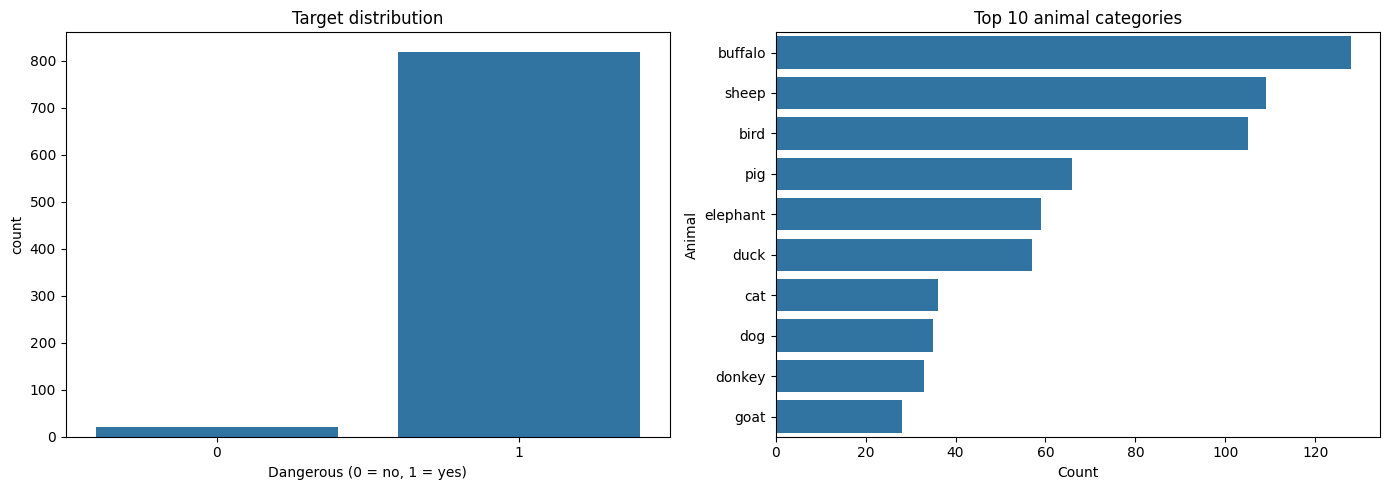

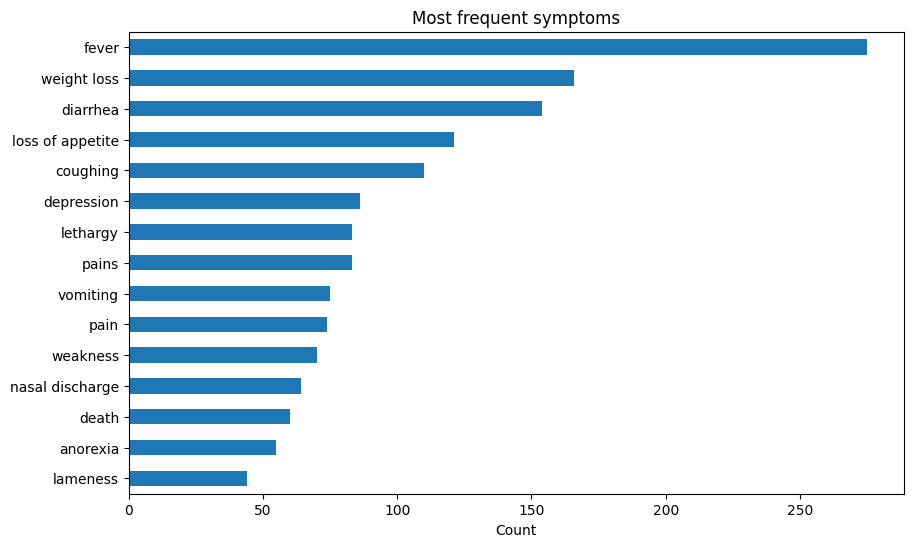

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=TARGET, ax=axes[0])
axes[0].set_title("Target distribution")
axes[0].set_xlabel("Dangerous (0 = no, 1 = yes)")

sns.countplot(
    data=df, y="Animal",
    order=df["Animal"].value_counts().head(10).index,
    ax=axes[1]
)
axes[1].set_title("Top 10 animal categories")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

all_symptoms = pd.concat([df[f"Symptom {i}"] for i in range(1, 6)])
top_symptoms = (
    all_symptoms[all_symptoms != ""]
    .value_counts()
    .head(15)
    .sort_values()
)
plt.figure(figsize=(10, 6))
top_symptoms.plot(kind="barh")
plt.title("Most frequent symptoms")
plt.xlabel("Count")
plt.show()

## 4. Leakage-safe model selection

The data is divided into training and test sets before the categorical encoder is fitted. Each encoder is included within its model pipeline, ensuring that category information is learned only from the relevant training data.

The models are compared using stratified five-fold cross-validation. F1-score is used as the primary selection metric because it balances precision and recall under class imbalance.

In [4]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

def make_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_pipeline(model):
    preprocessor = ColumnTransformer(
        [("categorical", make_encoder(), FEATURES)],
        remainder="drop"
    )
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(
            class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
        )
    ),
    "Linear SVM": make_pipeline(
        SVC(
            kernel="linear", probability=True,
            class_weight="balanced", random_state=RANDOM_STATE
        )
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
        )
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_rows = []
for name, pipeline in models.items():
    scores = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=scoring, n_jobs=1
    )
    cv_rows.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("CV F1", ascending=False)
display(cv_results.style.format({c: "{:.3f}" for c in cv_results.columns if c != "Model"}))
cv_results.to_csv("model_comparison.csv", index=False)

best_name = cv_results.iloc[0]["Model"]
best_pipeline = models[best_name]
print("Selected model:", best_name)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
1,Linear SVM,0.988,0.991,0.997,0.994,0.975
0,Logistic Regression,0.988,0.994,0.994,0.994,0.989
2,Random Forest,0.973,0.982,0.991,0.986,0.976


Selected model: Linear SVM


## 5. Evaluation on the held-out test set

After model selection, the candidate models are fitted using the training data and evaluated on the held-out test set. This provides an estimate of performance on previously unseen records.

The confusion matrices show the number of correct and incorrect predictions for each class. The classification report provides the final precision, recall, and F1-score values.

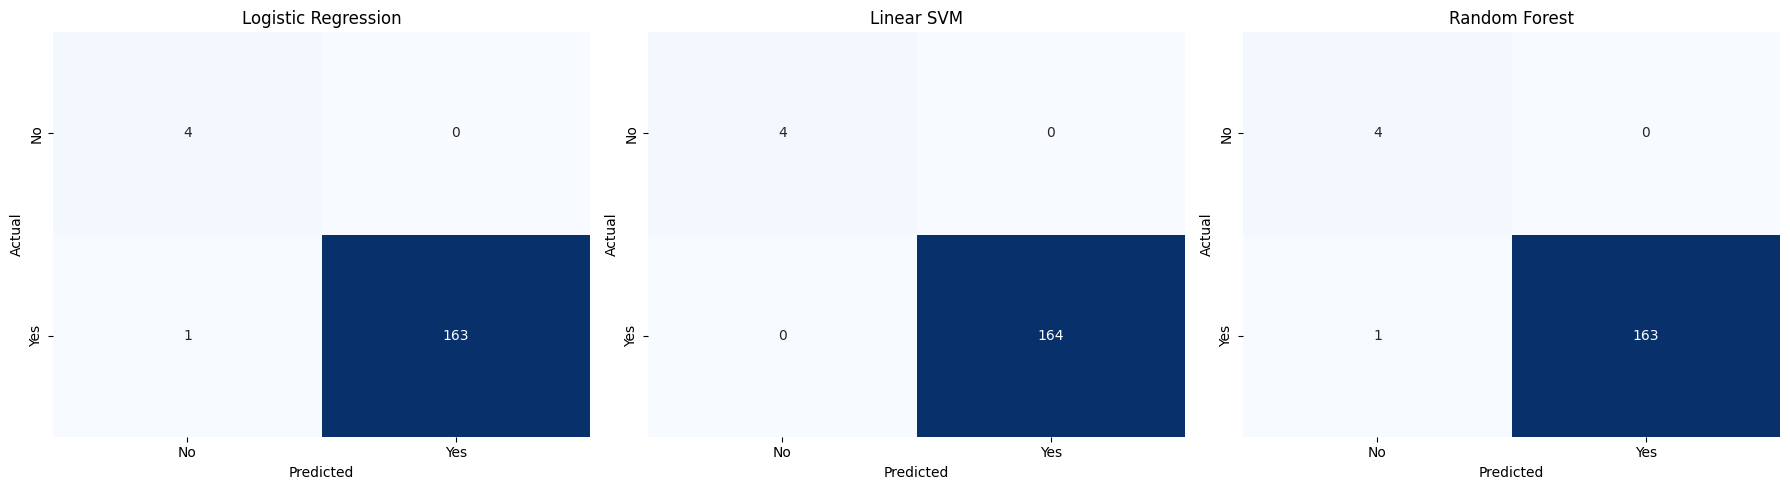

,Model,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
1,Linear SVM,1.000,1.000,1.000,1.000,1.000
0,Logistic Regression,0.994,1.000,0.994,0.997,1.000
2,Random Forest,0.994,1.000,0.994,0.997,0.997


Final selected model: Linear SVM
               precision    recall  f1-score   support

not dangerous       1.00      1.00      1.00         4
    dangerous       1.00      1.00      1.00       164

     accuracy                           1.00       168
    macro avg       1.00      1.00      1.00       168
 weighted avg       1.00      1.00      1.00       168



In [5]:
test_rows = []
fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (name, pipeline) in zip(axes, models.items()):
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    probabilities = pipeline.predict_proba(X_test)[:, 1]

    test_rows.append({
        "Model": name,
        "Test Accuracy": accuracy_score(y_test, predictions),
        "Test Precision": precision_score(y_test, predictions, zero_division=0),
        "Test Recall": recall_score(y_test, predictions, zero_division=0),
        "Test F1": f1_score(y_test, predictions, zero_division=0),
        "Test ROC-AUC": roc_auc_score(y_test, probabilities),
    })

    cm = confusion_matrix(y_test, predictions, labels=[0, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["No", "Yes"], yticklabels=["No", "Yes"]
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

test_results = pd.DataFrame(test_rows).sort_values("Test F1", ascending=False)
display(test_results.style.format({c: "{:.3f}" for c in test_results.columns if c != "Model"}))
test_results.to_csv("model_comparison_test.csv", index=False)

# Refit only the selected model on all training data for interpretation.
best_pipeline = models[best_name]
best_pipeline.fit(X_train, y_train)
best_predictions = best_pipeline.predict(X_test)

print(f"Final selected model: {best_name}")
print(classification_report(
    y_test, best_predictions,
    target_names=["not dangerous", "dangerous"],
    zero_division=0
))

## 6. Results and discussion

The Linear SVM was selected as the best model based on the highest cross-validated F1-score. This means it provided the strongest balance between precision and recall during model selection.

On the test set, the selected model classified all test examples correctly, including the four cases in the non-dangerous class. However, this result should be interpreted cautiously. The non-dangerous class contains only 20 records in total, and only four were included in the test set. A small change in these observations could significantly change the reported metrics.

The analysis would be more reliable with:

- More non-dangerous examples
- Independent records collected from different cases
- Veterinary-confirmed labels
- Additional information such as animal age, breed, location, disease type, and symptom severity
- A larger test set with a more balanced class distribution

## 7. Conclusion

This project shows that animal type and symptoms can be used to build a basic classification model for identifying cases marked as dangerous in this dataset. Among the models tested, Linear SVM produced the strongest cross-validated F1-score and achieved perfect performance on the held-out test set.

The main limitation is the severe class imbalance, especially the very small number of non-dangerous cases. Therefore, the current results show that the model can learn patterns in this dataset, but they do not prove that it would perform equally well on new real-world cases.

Overall, the project provides a useful starting point for animal-disease risk classification. Future work should focus on collecting a larger and more balanced dataset, validating the labels, and testing the model on an independent external dataset.